# Robustness to partial observations — PSS sequence partial observations

A key question for practical applicability is how inference behaves when observations are incomplete.
Transcriptomic experiments capture snapshots of cellular states at discrete time points: the dynamics
unfolding between successive snapshots are unobserved, and any given time point may simply not have
been collected, yield insufficient sequencing coverage, or fail binarization quality filters entirely.

In our framework, an observation corresponds to a **pseudo-steady state (PSS)**, a snapshot of the
system in which receptors and ligands have reached a stable configuration given the current signaling
context. The inference is driven by a sequence of such PSS snapshots over time. Partial observations
can arise at two levels: within a PSS (some components unobserved at a known time point) or at the
sequence level (an entire time point omitted). The former is addressed in a companion notebook on PSS
partial observations. Here we focus on the latter, stronger form of incompleteness: **PSS sequence
partial observations**.

Omitting a time point means that the transition between its two flanking snapshots must be explained
without any intermediate constraint. Rather than missing some components at a known moment, the
system's state at that moment is entirely unobserved, and the inference must find Boolean rules
consistent with a transition that could involve an arbitrary number of intermediate steps between the
two surrounding PSS snapshots. This substantially expands the solution space: fewer constraints admit
a larger ensemble of compatible networks, and edges that were previously incompatible with the full
observation sequence may now become admissible.

## Influence graph structure of the complete-observation ensemble

Before evaluating robustness to missing time points, we characterize the reference ensemble inferred
from the full observation sequence.

BoNesis exhaustively enumerates all minimal influence graphs consistent with the complete PSS
sequence, producing 448 distinct graphs. We aggregate them into a single stacked influence graph
where each edge carries the count of networks in which it appears. This reveals a structural split
that maps onto the bipartite architecture of the framework:

- **R → L edges** (within-cell, ligand secretion rules) are highly concentrated: most appear in all
  448 networks, meaning the observations tightly constrain how each cell translates receptor inputs
  into secretion outputs.
- **L → R edges** (cross-cell, receptor activation rules) are more variable: multiple alternative
  wiring patterns are compatible with the observed dynamics, reflecting the intrinsic
  under-determination of cross-cell signaling by temporal snapshots alone.

We distinguish **core edges**, present in all 448 influence graphs and therefore structurally
necessary, from **variable edges**, present in a subset and representing equivalent alternative
wirings. The complete ensemble contains 13 core edges and 21 variable edges (34 total). This
partition serves as the reference for all holdout comparisons below.

## PSS sequence partial observations

We evaluate five holdout conditions by omitting each time point $T_1$ through $T_5$ in turn. For
each condition, the two flanking PSS snapshots are retained but no intermediate constraint is
imposed: the inference is free to bridge the gap through any number of intermediate steps. We run
the full BoNesis inference pipeline on each reduced sequence and compare the resulting influence
graph ensemble to the 448-graph complete-observation reference using the following edge
classification:

- **Core → Recovered**: core edges in the complete ensemble that remain present in the partial ensemble.
- **Core → Lost**: core edges that disappear under the reduced constraints.
- **Variable → Recovered**: variable edges that remain present.
- **Variable → Lost**: variable edges that disappear.
- **New**: edges absent from the complete ensemble that become admissible under the reduced
  constraints — a direct consequence of the relaxed sequence, as removing a time point removes the
  two fixed-point constraints encoding its transitions.

Beyond structural comparison, we also test each inferred model for its ability to **reproduce the
complete trajectory** $PSS_1 \to PSS_2 \to PSS_3 \to PSS_4 \to PSS_5$ under Most Permissive (MP)
simulation, including the held-out PSS that was never used during inference. This tests whether the
dynamical constraints encoded by the remaining snapshots, combined with the bipartite dependency
structure, are sufficient to produce models that recover the unobserved dynamics.

### Influence graph comparison across holdout conditions

In [1]:
from Inference_CCC_PartialObs_PSSsequence import *

In [2]:
# Complete observations with one state changed at each time step
R_A = {
        'T1': {'R1_A': 1, 'R2_A': 0},
        'T2': {'R1_A': 1, 'R2_A': 0},
        'T3': {'R1_A': 1, 'R2_A': 1},
        'T4': {'R1_A': 1, 'R2_A': 1},
        'T5': {'R1_A': 0, 'R2_A': 1},
        'T6': {'R1_A': 0, 'R2_A': 1},
        'T7': {'R1_A': 0, 'R2_A': 1},
        'T8': {'R1_A': 0, 'R2_A': 1}
    }

R_B = {
        'T1': {'R1_B': 1, 'R2_B': 0},
        'T2': {'R1_B': 1, 'R2_B': 0},
        'T3': {'R1_B': 0, 'R2_B': 1},
        'T4': {'R1_B': 0, 'R2_B': 1},
        'T5': {'R1_B': 0, 'R2_B': 0},
        'T6': {'R1_B': 0, 'R2_B': 0},
        'T7': {'R1_B': 1, 'R2_B': 1},
        'T8': {'R1_B': 1, 'R2_B': 1}
    }

L_A = {
        'T1': {'L1_A': 1, 'L2_A': 0, 'L3_A': 0, 'L4_A': 0},
        'T2': {'L1_A': 1, 'L2_A': 1, 'L3_A': 0, 'L4_A': 0},
        'T3': {'L1_A': 1, 'L2_A': 1, 'L3_A': 0, 'L4_A': 0},
        'T4': {'L1_A': 1, 'L2_A': 1, 'L3_A': 1, 'L4_A': 0},
        'T5': {'L1_A': 1, 'L2_A': 1, 'L3_A': 1, 'L4_A': 0},
        'T6': {'L1_A': 0, 'L2_A': 0, 'L3_A': 0, 'L4_A': 1},
        'T7': {'L1_A': 0, 'L2_A': 0, 'L3_A': 0, 'L4_A': 1},
        'T8': {'L1_A': 0, 'L2_A': 0, 'L3_A': 0, 'L4_A': 1}
    }

L_B = {
        'T1': {'L1_B': 1, 'L2_B': 0, 'L3_B': 0, 'L4_B': 0},
        'T2': {'L1_B': 1, 'L2_B': 1, 'L3_B': 0, 'L4_B': 0},
        'T3': {'L1_B': 1, 'L2_B': 1, 'L3_B': 0, 'L4_B': 0},
        'T4': {'L1_B': 0, 'L2_B': 0, 'L3_B': 1, 'L4_B': 0},
        'T5': {'L1_B': 0, 'L2_B': 0, 'L3_B': 1, 'L4_B': 0},
        'T6': {'L1_B': 0, 'L2_B': 0, 'L3_B': 0, 'L4_B': 0},
        'T7': {'L1_B': 0, 'L2_B': 0, 'L3_B': 0, 'L4_B': 0},
        'T8': {'L1_B': 0, 'L2_B': 0, 'L3_B': 0, 'L4_B': 1}
    }

R = {"A": R_A, "B": R_B}
L = {"A": L_A, "B": L_B}

# Create the observation data
obs_df, compr_obs_df, cells, influences, all_receptors, all_ligands = create_observation_data(R, L)

In [3]:
results = run_full_workflow(compr_obs_df, cells, influences, limit_igs=1000, limit_bns=0, details=False)

Enumerating up to 1000 influence graphs with their Boolean networks...


Enumerating IG+BN pairs: 0it [00:00, ?it/s]

Grounding...done in 0.1s


Enumerating IG+BN pairs: 448it [00:02, 200.74it/s]


Found 448 influence graphs with their Boolean networks
limit_bns=0, skipping additional diverse Boolean networks.
Total: 448 Boolean networks
Enumerating up to 1000 influence graphs with their Boolean networks...


...

Found 1000 influence graphs with their Boolean networks
limit_bns=0, skipping additional diverse Boolean networks.
Total: 1000 Boolean networks
Enumerating up to 1000 influence graphs with their Boolean networks...


Enumerating IG+BN pairs: 0it [00:00, ?it/s]

Grounding...done in 0.1s


Enumerating IG+BN pairs: 1000it [00:03, 265.97it/s]

Found 1000 influence graphs with their Boolean networks
limit_bns=0, skipping additional diverse Boolean networks.
Total: 1000 Boolean networks


In [4]:
results.keys()

dict_keys(['bns_all_observations', 'igs_all_observations', 'bns_missingT1', 'igs_missingT1', 'bns_missingT2', 'igs_missingT2', 'bns_missingT3', 'igs_missingT3', 'bns_missingT4', 'igs_missingT4', 'bns_missingT5', 'igs_missingT5'])

## Influence graphs plots

In [14]:
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def classify_edges(igs_complete, igs_partial):
    """
    Classify all edges relative to the complete ensemble.
    An edge "exists" in an ensemble if it appears in at least one model.
    """
    n_complete = len(igs_complete)

    def count_edges(igs):
        c = Counter()
        for ig in igs:
            for src, tgt, data in ig.edges(data=True):
                sign = data.get("sign", data.get("weight", 1))
                c[(src, tgt, sign)] += 1
        return c

    counts_c = count_edges(igs_complete)
    counts_p = count_edges(igs_partial)

    core_edges     = {e for e, c in counts_c.items() if c == n_complete}
    variable_edges = {e for e, c in counts_c.items() if 0 < c < n_complete}
    complete_edges = core_edges | variable_edges
    partial_edges  = set(counts_p.keys())

    return {
        "core_recovered":     core_edges & partial_edges,       # core in complete, present in partial
        "core_lost":          core_edges - partial_edges,        # core in complete, absent in partial
        "variable_recovered": variable_edges & partial_edges,   # variable in complete, present in partial
        "variable_lost":      variable_edges - partial_edges,    # variable in complete, absent in partial
        "new":           partial_edges - complete_edges,    # absent in complete, present in partial
    }


def plot_influence_graphs_compAllObs( # Plot with edge classification compared to complete ensemble 
    igs,
    igs_complete=None,
    title="Influence Graph",
    layout='cose',
    node_positions=None
):
    """
    Plot influence graphs stacked together with edge classification.

    Colors indicate origin relative to the complete ensemble:
        core_still_core
        core_to_variable
        variable
        new

    Lost edges are not plotted.
    """

    import ipycytoscape
    from collections import Counter

    # -------------------------------------------------------
    # CLASSIFY EDGES (if complete ensemble provided)
    # -------------------------------------------------------

    core_still_core = set()
    core_to_variable = set()
    variable_edges = set()
    new = set()

    if igs_complete is not None:
        classified = classify_edges(igs_complete, igs)

        core_still_core = classified["core_recovered"]   # core in complete, still present
        core_to_variable = set()                          # no longer tracked this way
        variable_edges = classified["variable_recovered"] # variable in complete, still present
        new = classified["new"]                           # absent in complete, appeared in partial

    # -------------------------------------------------------
    # EDGE FREQUENCY
    # -------------------------------------------------------

    all_edges = []

    for ig in igs:
        for source, target, data in ig.edges(data=True):
            sign = data.get("sign", data.get("weight", 1))
            all_edges.append((source, target, sign))

    edge_counts = Counter(all_edges)
    max_edge_freq = max(edge_counts.values()) if edge_counts else 1

    # -------------------------------------------------------
    # CREATE CYTOSCAPE
    # -------------------------------------------------------

    cytoscapeobj = ipycytoscape.CytoscapeWidget()
    cytoscapeobj.graph.directed = True

    # -------------------------------------------------------
    # COLLECT NODES
    # -------------------------------------------------------

    all_nodes = set()
    for ig in igs:
        all_nodes.update(ig.nodes())

    # -------------------------------------------------------
    # ADD NODES
    # -------------------------------------------------------

    for node in all_nodes:

        if node_positions is not None:
            x, y = node_positions.get(node, (0, 0))
        else:
            x, y = (0, 0)

        cytoscapeobj.graph.add_node(
            ipycytoscape.Node(
                data={'id': node, 'label': node},
                position={'x': x, 'y': y},
                locked=(node_positions is not None)
            )
        )

    # -------------------------------------------------------
    # EDGE COLOR BY CLASS
    # -------------------------------------------------------

    def classify_edge(e):

        if e in core_still_core:
            return "core"

        if e in core_to_variable:
            return "weakened"

        if e in variable_edges:
            return "variable"

        if e in new:
            return "new"

        return "unknown"

    # -------------------------------------------------------
    # ADD EDGES
    # -------------------------------------------------------

    for (source, target, sign), freq in edge_counts.items():

        normalized = freq / max_edge_freq
        edge_class = classify_edge((source, target, sign))

        cytoscapeobj.graph.add_edge(
            ipycytoscape.Edge(
                data={
                    'source': source,
                    'target': target,
                    'frequency': freq,
                    'label': str(freq)
                },
                classes=f"{edge_class} {'positive' if sign==1 else 'negative'}"
            )
        )

    # -------------------------------------------------------
    # STYLE
    # -------------------------------------------------------

    cytoscapeobj.set_style([

        # nodes
        {
            'selector': 'node',
            'style': {
                'background-color': '#D3D3D3',
                'label': 'data(label)',
                'text-valign': 'center',
                'color': 'black',
                'text-outline-width': 2,
                'text-outline-color': 'white',
                'font-size': '14px',
                'font-weight': 'bold',
                'width': 50,
                'height': 50
            }
        },

        # base edge
        {
            'selector': 'edge',
            'style': {
                'target-arrow-shape': 'none',
                'arrow-scale': 2,
                'width': f'mapData(frequency, 1, {max_edge_freq}, 2, 5)',
                'curve-style': 'bezier',
                'opacity': f'mapData(frequency, 1, {max_edge_freq}, 0.4, 1.0)',
                'label': 'data(label)',
                'font-size': '10px'
            }
        },

        # sign
        {
            'selector': 'edge.positive',
            'style': {
                'target-arrow-shape': 'triangle'
            }
        },

        {
            'selector': 'edge.negative',
            'style': {
                'target-arrow-shape': 'tee',
                'line-style': 'dashed'
            }
        },

        # -------------------
        # CLASS COLORS
        # -------------------

        # robust core
        {
            'selector': 'edge.core',
            'style': {
                'line-color': "#0E67C0",
                'target-arrow-color': "#0E67C0"
            }
        },

        # weakened core
        {
            'selector': 'edge.weakened',
            'style': {
                'line-color': "#E58525",
                'target-arrow-color': "#E58525"
            }
        },

        # variable
        {
            'selector': 'edge.variable',
            'style': {
                'line-color': "#2AABE7",
                'target-arrow-color': "#2AABE7"
            }
        },

        # new
        {
            'selector': 'edge.new',
            'style': {
                'line-color': "#D4C900",
                'target-arrow-color': "#D4C900",
                'line-style': 'dotted'
            }
        }

    ])

    # -------------------------------------------------------
    # LAYOUT
    # -------------------------------------------------------

    if node_positions is not None:
        cytoscapeobj.set_layout(name='preset', animate=False)
    else:
        cytoscapeobj.set_layout(name=layout, animate=True)

    return cytoscapeobj


node_positions = {
    # Cell A — receptors (top row)
    'R1_A': (100, 50),
    'R2_A': (250, 50),
    # Cell B — receptors (top row)
    'R1_B': (425, 50),
    'R2_B': (550, 50),
    # Cell A — ligands (bottom row)
    'L1_A': (25,  300),
    'L2_A': (100, 300),
    'L3_A': (175, 300),
    'L4_A': (250, 300),
    # Cell B — ligands (bottom row)
    'L1_B': (375, 300),
    'L2_B': (450, 300),
    'L3_B': (525, 300),
    'L4_B': (600, 300),
}

In [15]:
node_positions = {
    # Cell A — receptors (top row)
    'R1_A': (100, 50),
    'R2_A': (250, 50),
    # Cell B — receptors (top row)
    'R1_B': (425, 50),
    'R2_B': (550, 50),
    # Cell A — ligands (bottom row)
    'L1_A': (25,  300),
    'L2_A': (100, 300),
    'L3_A': (175, 300),
    'L4_A': (250, 300),
    # Cell B — ligands (bottom row)
    'L1_B': (375, 300),
    'L2_B': (450, 300),
    'L3_B': (525, 300),
    'L4_B': (600, 300),
}

In [16]:
plot_influence_graphs(results["igs_all_observations"], node_positions=node_positions)

CytoscapeWidget(cytoscape_layout={'name': 'preset', 'animate': True}, cytoscape_style=[{'selector': 'node', 's…

### T1 is held out

In [17]:
plot_influence_graphs(results["igs_missingT1"], node_positions=node_positions)

CytoscapeWidget(cytoscape_layout={'name': 'preset', 'animate': True}, cytoscape_style=[{'selector': 'node', 's…

In [18]:
plot_influence_graphs_compAllObs(results["igs_all_observations"], igs_complete=results["igs_all_observations"], node_positions=node_positions)

CytoscapeWidget(cytoscape_layout={'name': 'preset', 'animate': False}, cytoscape_style=[{'selector': 'node', '…

### T2 is held out

In [19]:
plot_influence_graphs(results["igs_missingT2"], node_positions=node_positions)

CytoscapeWidget(cytoscape_layout={'name': 'preset', 'animate': True}, cytoscape_style=[{'selector': 'node', 's…

In [20]:
plot_influence_graphs_compAllObs(results["igs_missingT2"], igs_complete=results["igs_all_observations"], node_positions=node_positions)

CytoscapeWidget(cytoscape_layout={'name': 'preset', 'animate': False}, cytoscape_style=[{'selector': 'node', '…

### T3 is held out

In [21]:
plot_influence_graphs(results["igs_missingT3"], node_positions=node_positions)

CytoscapeWidget(cytoscape_layout={'name': 'preset', 'animate': True}, cytoscape_style=[{'selector': 'node', 's…

In [22]:
plot_influence_graphs_compAllObs(results["igs_missingT3"], igs_complete=results["igs_all_observations"], node_positions=node_positions)

CytoscapeWidget(cytoscape_layout={'name': 'preset', 'animate': False}, cytoscape_style=[{'selector': 'node', '…

### T4 is held out

In [23]:
plot_influence_graphs(results["igs_missingT4"], node_positions=node_positions)

CytoscapeWidget(cytoscape_layout={'name': 'preset', 'animate': True}, cytoscape_style=[{'selector': 'node', 's…

In [24]:
plot_influence_graphs_compAllObs(results["igs_missingT4"], igs_complete=results["igs_all_observations"], node_positions=node_positions)

CytoscapeWidget(cytoscape_layout={'name': 'preset', 'animate': False}, cytoscape_style=[{'selector': 'node', '…

### T5 is held out

In [25]:
plot_influence_graphs(results["igs_missingT5"], node_positions=node_positions)

CytoscapeWidget(cytoscape_layout={'name': 'preset', 'animate': True}, cytoscape_style=[{'selector': 'node', 's…

In [29]:
plot_influence_graphs_compAllObs(results["igs_missingT5"], igs_complete=results["igs_all_observations"], node_positions=node_positions)

CytoscapeWidget(cytoscape_layout={'name': 'preset', 'animate': False}, cytoscape_style=[{'selector': 'node', '…

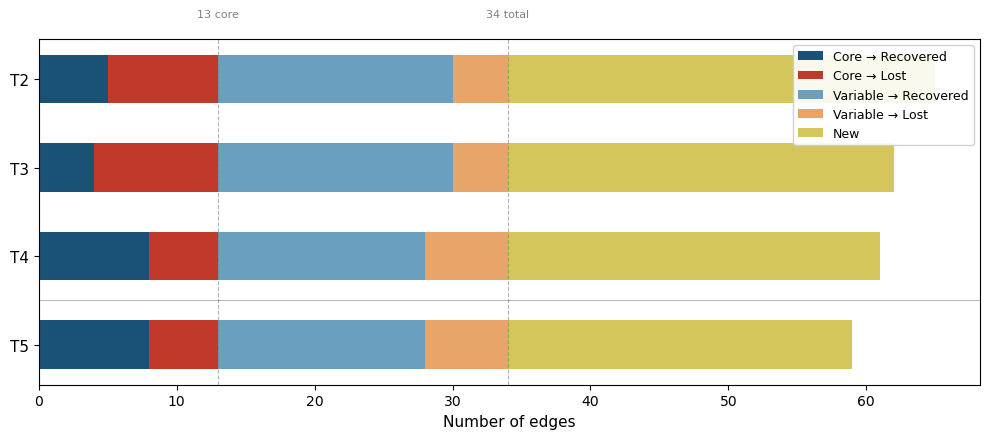

In [28]:
# ── Compute classifications ───────────────────────────────────────────────────

conditions = {
    "T2": (results["igs_all_observations"], results["igs_missingT2"]),
    "T3": (results["igs_all_observations"], results["igs_missingT3"]),
    "T4": (results["igs_all_observations"], results["igs_missingT4"]),
    "T5": (results["igs_all_observations"], results["igs_missingT5"]),
}

results_classified = {
    label: classify_edges(igs_c, igs_p)
    for label, (igs_c, igs_p) in conditions.items()
}

# ── Extract arrays ────────────────────────────────────────────────────────────

labels = list(results_classified.keys())
core_recovered     = [len(r["core_recovered"])     for r in results_classified.values()]
core_lost          = [len(r["core_lost"])           for r in results_classified.values()]
variable_recovered = [len(r["variable_recovered"]) for r in results_classified.values()]
variable_lost      = [len(r["variable_lost"])       for r in results_classified.values()]
new                = [len(r["new"])                 for r in results_classified.values()]

# Reference line values — computed from the first complete ensemble
igs_c_ref = conditions[labels[0]][0]
from collections import Counter
def _count(igs):
    c = Counter()
    for ig in igs:
        for src, tgt, data in ig.edges(data=True):
            sign = data.get("sign", data.get("weight", 1))
            c[(src, tgt, sign)] += 1
    return c
counts_ref = _count(igs_c_ref)
n_complete_ref = len(igs_c_ref)
n_core = sum(1 for c in counts_ref.values() if c == n_complete_ref)
n_var  = sum(1 for c in counts_ref.values() if 0 < c < n_complete_ref)

# ── Plot ──────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np

c_core_recovered     = "#1a5276"
c_core_lost          = "#c0392b"
c_variable_recovered = "#6A9FC0"
c_variable_lost      = "#E8A56A"
c_new                = "#d4c65a"

fig, ax = plt.subplots(figsize=(10, 4.5))

y = np.arange(len(labels))
bar_height = 0.55
left = np.zeros(len(labels))

ax.barh(y, core_recovered, height=bar_height, left=left, color=c_core_recovered, label="Core → Recovered")
left += np.array(core_recovered, dtype=float)

ax.barh(y, core_lost, height=bar_height, left=left, color=c_core_lost, label="Core → Lost")
left += np.array(core_lost, dtype=float)

ax.barh(y, variable_recovered, height=bar_height, left=left, color=c_variable_recovered, label="Variable → Recovered")
left += np.array(variable_recovered, dtype=float)

ax.barh(y, variable_lost, height=bar_height, left=left, color=c_variable_lost, label="Variable → Lost")
left += np.array(variable_lost, dtype=float)

ax.barh(y, new, height=bar_height, left=left, color=c_new, label="New")

# Reference lines
ax.axvline(n_core, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.axvline(n_core + n_var, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.text(n_core, -0.7, f"{n_core} core", ha="center", fontsize=8, color="gray")
ax.text(n_core + n_var, -0.7, f"{n_core + n_var} total", ha="center", fontsize=8, color="gray")

# Separator between R and L holdouts
ax.axhline(2.5, color="black", linestyle="-", linewidth=0.5, alpha=0.4)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel("Number of edges", fontsize=11)
ax.invert_yaxis()
ax.legend(loc="upper right", fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

In [33]:
def robustness_to_latex(results_classified, n_core, n_var, label, caption):
    latex = f"""\\begin{{table}}[h]
\\centering
\\small
\\begin{{tabular}}{{lccccc}}
\\hline
\\textbf{{Condition}} & \\textbf{{Core recovered}} & \\textbf{{Core lost}} & \\textbf{{Variable recovered}} & \\textbf{{Variable lost}} & \\textbf{{New}} \\\\
\\hline
"""
    for condition, r in results_classified.items():
        cr = len(r["core_recovered"])
        cl = len(r["core_lost"])
        vr = len(r["variable_recovered"])
        vl = len(r["variable_lost"])
        nw = len(r["new"])
        latex += f"{condition} & {cr}/{n_core} & {cl}/{n_core} & {vr}/{n_var} & {vl}/{n_var} & {nw} \\\\\n"

    latex += f"""\\hline
\\end{{tabular}}
\\caption{{{caption} Reference ensemble has {n_core} core and {n_var} variable edges ({n_core + n_var} total).}}
\\label{{{label}}}
\\end{{table}}"""
    return latex


# PSS sequence partial — directly from your existing results_classified
print(robustness_to_latex(
    results_classified,
    n_core=n_core,
    n_var=n_var,
    label="tab:pss_sequence_robustness",
    caption="Complete robustness results under PSS sequence partial observations.",
))

\begin{table}[h]
\centering
\small
\begin{tabular}{lccccc}
\hline
\textbf{Condition} & \textbf{Core recovered} & \textbf{Core lost} & \textbf{Variable recovered} & \textbf{Variable lost} & \textbf{New} \\
\hline
T2 & 5/13 & 8/13 & 17/21 & 4/21 & 31 \\
T3 & 4/13 & 9/13 & 17/21 & 4/21 & 28 \\
T4 & 8/13 & 5/13 & 15/21 & 6/21 & 27 \\
T5 & 8/13 & 5/13 & 15/21 & 6/21 & 25 \\
\hline
\end{tabular}
\caption{Complete robustness results under PSS sequence partial observations. Reference ensemble has 13 core and 21 variable edges (34 total).}
\label{tab:pss_sequence_robustness}
\end{table}
